# Practical 8: Confidence Interval and Bootstrapping


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the supermarket_sales.csv dataset into a Pandas DataFrame
# Update the path below if the dataset is in a different location
df = pd.read_csv('supermarket_sales.csv')

In [5]:
# Display the first five records and check the size of the dataset
print(df.head())
print("\nDataset size:", df.shape)

    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33         7      16.2155  340.5255   
3       Health and beauty      58.22         8      23.2880  489.0480   
4       Sports and travel      86.31         7      30.2085  634.3785   

        date   time payment_method    cogs    gm_pct  gross_income  rating  
0   01/05/19  13:08        Ewallet  522.83  4.761905       26.1415     9.1  
1   03/08/

In [6]:
# Select the revenue column for analysis
revenue = df['revenue']

In [7]:
# Check and handle missing values in the selected column
print("Missing values in revenue:", revenue.isnull().sum())
revenue = revenue.dropna()

Missing values in revenue: 0


In [8]:
# Calculate the sample size, sample mean, and sample standard deviation
n = len(revenue)
sample_mean = revenue.mean()
sample_std = revenue.std()
print(f"Sample Size: {n}")
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Std: {sample_std:.2f}")

Sample Size: 1000
Sample Mean: 322.97
Sample Std: 245.89


In [9]:
# Helper function to calculate confidence interval
def calculate_ci(mean, std, n, confidence=0.95):
    z = stats.norm.ppf((1 + confidence) / 2)
    margin_of_error = z * (std / np.sqrt(n))
    return mean - margin_of_error, mean + margin_of_error

# Calculate 90%, 95%, and 99% confidence intervals
ci_90 = calculate_ci(sample_mean, sample_std, n, 0.90)
ci_95 = calculate_ci(sample_mean, sample_std, n, 0.95)
ci_99 = calculate_ci(sample_mean, sample_std, n, 0.99)

In [10]:
# Display the confidence intervals in a suitable table
ci_data = {
    "Confidence Level": ["90%", "95%", "99%"],
    "Lower Bound": [ci_90[0], ci_95[0], ci_99[0]],
    "Upper Bound": [ci_90[1], ci_95[1], ci_99[1]]
}
ci_df = pd.DataFrame(ci_data)
print(ci_df)

  Confidence Level  Lower Bound  Upper Bound
0              90%   310.177063   335.756435
1              95%   307.726898   338.206600
2              99%   302.938190   342.995308


## Comparison and Interpretation

In [11]:
# Compare the 90%, 95%, and 99% confidence intervals
print("Observation: As the confidence level increases, the width of the confidence interval also increases.")

Observation: As the confidence level increases, the width of the confidence interval also increases.


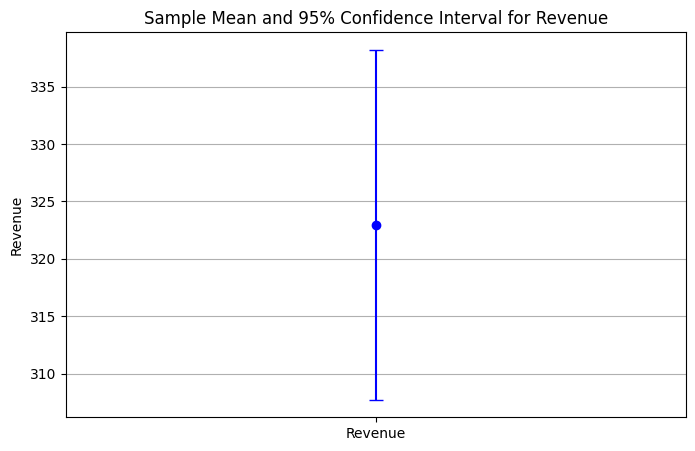

In [12]:
# Visualization to display the sample mean and confidence interval
plt.figure(figsize=(8, 5))
plt.errorbar(x=[0], y=[sample_mean], yerr=[[sample_mean - ci_95[0]], [ci_95[1] - sample_mean]], fmt='o', color='b', capsize=5)
plt.title("Sample Mean and 95% Confidence Interval for Revenue")
plt.ylabel("Revenue")
plt.xticks([0], ['Revenue'])
plt.grid(True, axis='y')
plt.show()

### Interpretation of 95% CI

In [13]:
print(f"Interpretation: We are 95% confident that the true population mean revenue for the supermarket lies between {ci_95[0]:.2f} and {ci_95[1]:.2f}.")

Interpretation: We are 95% confident that the true population mean revenue for the supermarket lies between 307.73 and 338.21.


In [14]:
# Select the customer_type column and calculate the proportion of customers
prop_customers = df['customer_type'].value_counts(normalize=True)
print("Proportion of customers by category:\n", prop_customers)

# Calculate the 95% confidence interval for the proportion of Member customers
p_member = prop_customers['Member']
n_total = len(df['customer_type'])
z_95 = stats.norm.ppf(0.975)
margin_prop = z_95 * np.sqrt((p_member * (1 - p_member)) / n_total)
prop_ci = (p_member - margin_prop, p_member + margin_prop)
print(f"\n95% CI for Member Proportion: {prop_ci}")

Proportion of customers by category:
 customer_type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64

95% CI for Member Proportion: (np.float64(0.47001031036433716), np.float64(0.5319896896356628))


### Interpretation of Proportion CI

In [15]:
print(f"Interpretation: We are 95% confident that the true population proportion of Member customers is between {prop_ci[0]:.4f} and {prop_ci[1]:.4f} in a business context.")

Interpretation: We are 95% confident that the true population proportion of Member customers is between 0.4700 and 0.5320 in a business context.


# Part B: Bootstrapping

In [16]:
# Select the revenue column and calculate its original sample median
original_median = revenue.median()
print(f"Original Sample Median: {original_median:.2f}")

Original Sample Median: 253.85


In [17]:
# Bootstrapping process
bootstrap_medians = []
for _ in range(1000):
    # Create a bootstrap sample by randomly selecting observations with replacement
    boot_sample = np.random.choice(revenue, size=len(revenue), replace=True)
    # Calculate the median of the bootstrap sample
    bootstrap_medians.append(np.median(boot_sample))

print("Bootstrapping completed for 1,000 iterations.")

Bootstrapping completed for 1,000 iterations.


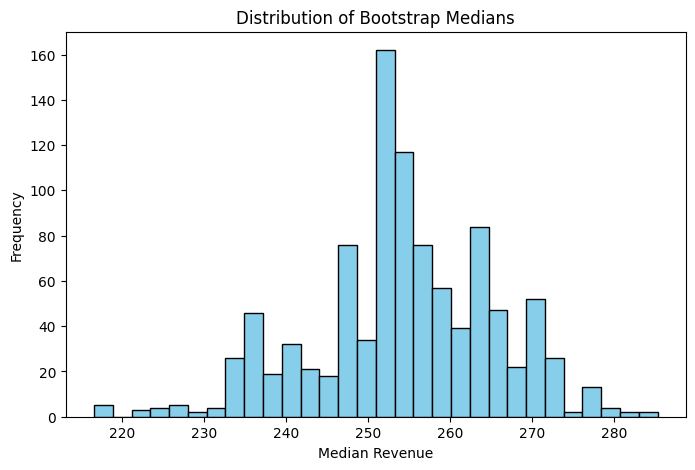

In [18]:
# Create a histogram of the bootstrap median values
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_medians, bins=30, edgecolor='black', color='skyblue')
plt.title("Distribution of Bootstrap Medians")
plt.xlabel("Median Revenue")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Calculate the 2.5th and 97.5th percentile of the bootstrap median values
lower_p = np.percentile(bootstrap_medians, 2.5)
upper_p = np.percentile(bootstrap_medians, 97.5)
boot_ci = (lower_p, upper_p)
print(f"95% Bootstrap Confidence Interval for the population median: {boot_ci}")

95% Bootstrap Confidence Interval for the population median: (np.float64(232.863225), np.float64(273.24084375))


In [20]:
# Display the original sample median and the bootstrap confidence interval
print(f"Original Sample Median: {original_median:.2f}")
print(f"Bootstrap CI: {boot_ci}")

# Compare the original median with the bootstrap confidence interval
is_within = boot_ci[0] <= original_median <= boot_ci[1]
print(f"Is original median within the Bootstrap CI? {is_within}")

Original Sample Median: 253.85
Bootstrap CI: (np.float64(232.863225), np.float64(273.24084375))
Is original median within the Bootstrap CI? True


### Interpretation and Conclusion

In [21]:
print(f"Interpretation: Based on 1,000 bootstrap samples, we are 95% confident that the population median revenue lies between {boot_ci[0]:.2f} and {boot_ci[1]:.2f}.")

Interpretation: Based on 1,000 bootstrap samples, we are 95% confident that the population median revenue lies between 232.86 and 273.24.


### Final Conclusion

In [22]:
conclusion = """
Conclusion:
Confidence intervals and bootstrapping allow businesses to quantify uncertainty when using sample data. 
Confidence intervals provide a range of plausible values for a population parameter (like mean revenue), 
helping managers avoid over-reliance on a single point estimate. 
Bootstrapping is particularly useful for parameters where traditional formulas are complex (like the median) 
or when the distribution is unknown, providing a robust way to estimate precision through resampling. 
Together, these tools enable data-driven decisions with a clear understanding of the associated risk and error.
"""
print(conclusion)


Conclusion:
Confidence intervals and bootstrapping allow businesses to quantify uncertainty when using sample data. 
Confidence intervals provide a range of plausible values for a population parameter (like mean revenue), 
helping managers avoid over-reliance on a single point estimate. 
Bootstrapping is particularly useful for parameters where traditional formulas are complex (like the median) 
or when the distribution is unknown, providing a robust way to estimate precision through resampling. 
Together, these tools enable data-driven decisions with a clear understanding of the associated risk and error.

